# CAMM Hackathon 15: Vector Field Problem - NanoLithography


- In scanning-probe nanolithography, a biased AFM tip can switch ferroelectric polarization not only through voltage amplitude, but also through the geometry of its motion.
- The tip trajectory creates an effective in-plane electric-field pattern that can guide local switching and stabilize designed domain configurations.

Examples:

[Vasudevan, R.; et al. On-demand nanoengineering of in-plane ferroelectric topologies](https://www.nature.com/articles/s41565-024-01792-1)

[Vasudevan R., et al. Deterministic arbitrary switching of polarization in a ferroelectric thin film](https://www.nature.com/articles/ncomms5971)

####Today, we are going to focus on **designing lithography trajectories** that generate target electric-field patterns in a minimal ferroelectric model.



We consider a sharp, electrically biased probe moving across a ferroelectric surface. As the probe moves, it can locally switch the material’s polarization, making the lithography trajectory itself part of the design problem.

Two key assumptions define the simplified model:

- A moving probe creates an effective trailing in-plane field in its wake. The local polarization tends to align with the direction of probe motion.
- At each moment, you control two main parameters: the probe position or path, and the applied voltage (V). In a more complete model, the probe speed could also be included, since it affects domain-growth dynamics and therefore the final written pattern.

In this simplified challenge, the effective writing field is approximated as


$\;\mathbf{E}_{\text{eff}} = V\cdot\hat{\mathbf t}\;$

where ($\hat{\mathbf t}$) is the local travel direction of the probe. The direction of motion sets the field orientation, the voltage sets its sign and strength, and larger ($|V|$) switches a wider region of the material.

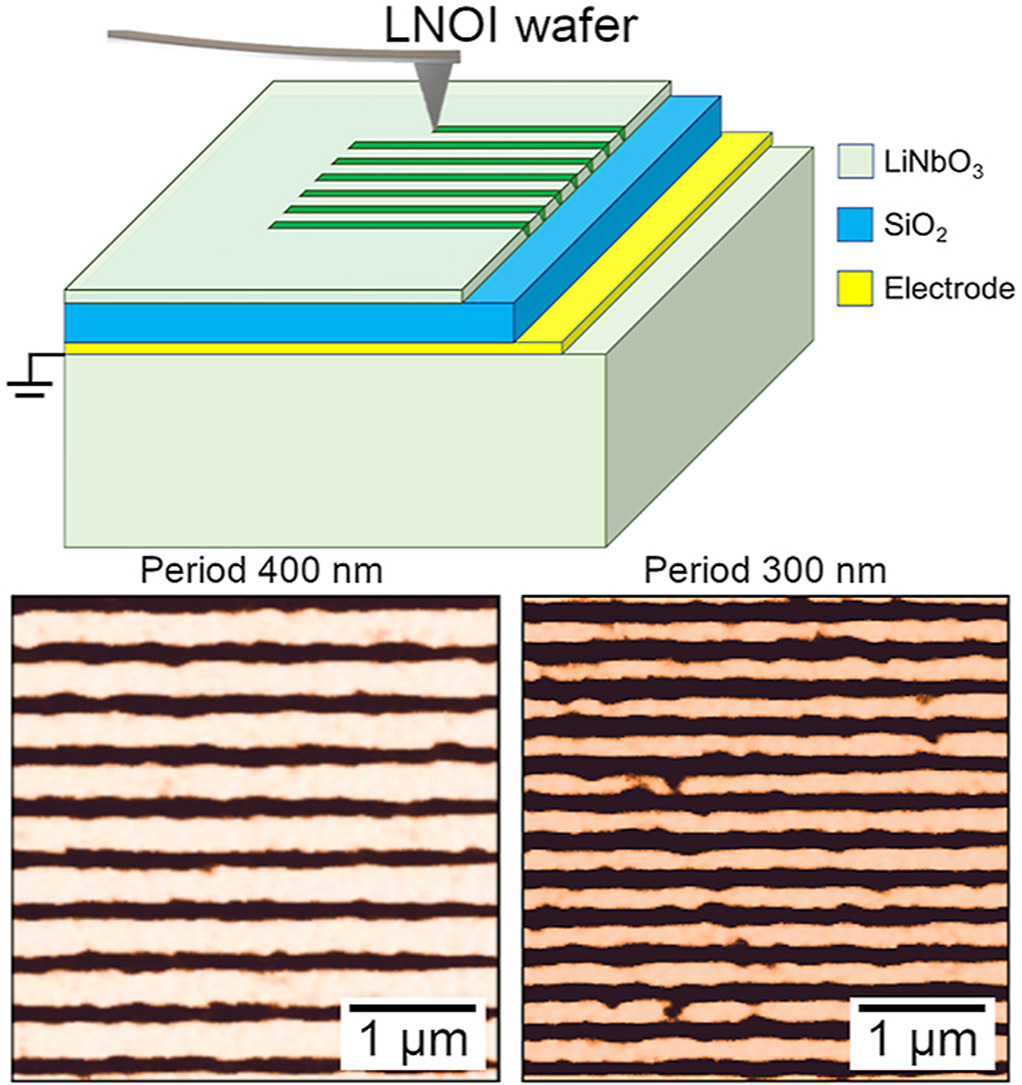

*https://www.sciencedirect.com/science/article/pii/S0272884221025785

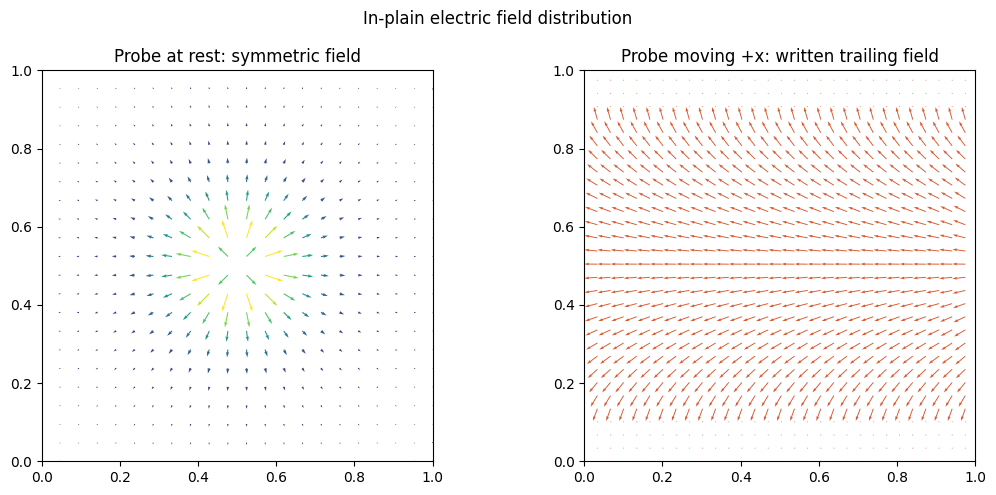

In [1]:
import numpy as np, matplotlib.pyplot as plt

h = 0.10                                   # pen (point-charge) height above the surface
def E(X, Y, xc, yc):                       # in-plane surface field from a charge at (xc, yc, h)
    dx, dy = X - xc, Y - yc
    r3 = (dx*dx + dy*dy + h*h)**1.5
    return dx/r3, dy/r3

fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# --- AT REST: charge sits at the centre -> symmetric field, no chosen direction ---
g = np.linspace(0, 1, 22); X, Y = np.meshgrid(g, g)
Ex, Ey = E(X, Y, 0.5, 0.5)
ax[0].quiver(X, Y, Ex, Ey, np.hypot(Ex, Ey), cmap="viridis", scale=800)
ax[0].set_title("Probe at rest: symmetric field")

# --- MOVING +x: the spot that switches LAST is written (overwrite) -> a trailing wake ---
gg = np.linspace(0, 1, 120); Xs, Ys = np.meshgrid(gg, gg)
Px = np.zeros_like(Xs); Py = np.zeros_like(Xs); Ec = 6.0     # switching threshold
for xc in np.linspace(-0.25, 1.25, 300):                     # pen sweeps left -> right
    ex, ey = E(Xs, Ys, xc, 0.5); m = np.hypot(ex, ey); sw = m > Ec
    Px[sw], Py[sw] = ex[sw]/m[sw], ey[sw]/m[sw]              # last write wins
s = slice(None, None, 4)
ax[1].quiver(Xs[s, s], Ys[s, s], Px[s, s], Py[s, s], color="#D85A30", scale=30)
ax[1].set_title("Probe moving +x: written trailing field")

for a in ax: a.set_aspect("equal"); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.suptitle('In-plain electric field distribution')
plt.tight_layout(); plt.show()

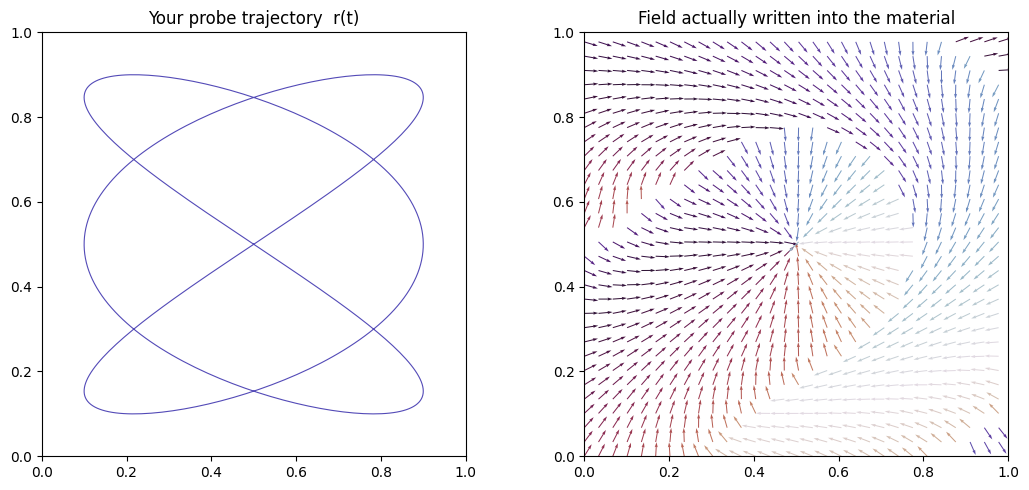

In [2]:
import numpy as np, matplotlib.pyplot as plt

h, Ec = 0.06, 12.0                         # pen height above surface, switching threshold
def Efield(X, Y, xc, yc, V):               # in-plane field of the charged pen (V scales it)
    dx, dy = X - xc, Y - yc; r3 = (dx*dx + dy*dy + h*h)**1.5
    return V*dx/r3, V*dy/r3

# ---- YOUR design: path r(t) + voltage V(t)  (sign of V = direction, |V| = brush width) ----
t = np.linspace(0, 1, 500)
def path(t): return 0.5 + 0.40*np.sin(2*np.pi*3*t), 0.5 + 0.40*np.sin(2*np.pi*2*t)
def volt(t): return np.where(t < 0.5, 1.0, -1.0)        # e.g. flip the sign halfway
xc, yc = path(t); V = volt(t)

# ---- write into the film: move the pen; the last above-threshold field wins (overwrite) ----
g = np.linspace(0, 1, 90); X, Y = np.meshgrid(g, g)
Px = np.full_like(X, np.nan); Py = np.full_like(X, np.nan)
for i in range(len(t)):
    ex, ey = Efield(X, Y, xc[i], yc[i], V[i]); m = np.hypot(ex, ey); sw = m > Ec
    Px[sw], Py[sw] = ex[sw]/m[sw], ey[sw]/m[sw]

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].plot(xc, yc, lw=.8, c="#534AB7"); ax[0].set_title("Your probe trajectory  r(t)")
s = slice(None, None, 3)
ax[1].quiver(X[s,s], Y[s,s], Px[s,s], Py[s,s], np.arctan2(Py, Px)[s,s],
             cmap="twilight", scale=30)
ax[1].set_title("Field actually written into the material")
for a in ax: a.set_aspect("equal"); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.tight_layout(); plt.show()

### Possible Problems to be Solves


#### **1. Prompt-to-trajectory generation**

Develop a system that converts a user request into a lithography trajectory.
For example, given prompts such as “write a vortex,” “create a centre-divergent pattern,” or “make a dense array of flux-closure-like structures,” the system should generate a probe path (x(t), y(t)) and voltage profile (V(t)).

#### 2. **Forward simulation of the written pattern (high complexity)**

Build a simplified model that predicts the resulting in-plane polarization or electric-field pattern from a proposed trajectory.
The model does not need to describe the full probe–sample physics, but should capture the main idea: probe motion defines the local field direction, voltage defines switching strength and sign, and material response can be approximated through simple parameters such as permittivity or switching width.

#### 3. **Trajectory optimization**

Given a target structure type and constraints, optimize the trajectory parameters.
Possible objectives include improving pattern quality, increasing feature density, reducing writing time, minimizing voltage exposure, or matching a desired domain size.

#### 4. **Inverse design from a target pattern**

Solve the inverse problem: given a desired vector-field image/pattern, generate a trajectory that could approximately write it.


The solution can be implemented either as an agentic system or as any other algorithmic approach.

In [3]:
# 1. Imports
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras

In [4]:
# ============================================================
# 2. Create material grid
# ============================================================

nx, ny = 150, 150

x = tf.linspace(0.0, 1.0, nx)
y = tf.linspace(0.0, 1.0, ny)

X, Y = tf.meshgrid(x, y)

grid_points = tf.stack(
    [tf.reshape(X, [-1]), tf.reshape(Y, [-1])],
    axis=1
)

print("Grid points shape:", grid_points.shape)

Grid points shape: (22500, 2)


In [5]:
# ============================================================
# 3. Dynamic trajectory generator
# ============================================================

def make_trajectory(
    line_spacing,
    voltage,
    trajectory_amplitude,
    trajectory_frequency,
    trajectory_phase,
    trajectory_offset,
    points_per_line=200,
    x_min=0.0,
    x_max=1.0,
    y_min=0.0,
    y_max=1.0,
    serpentine=True
):
    """
    Creates a lithography trajectory where the number of lines is determined
    automatically by how many lines fit inside the y-range.

    Returns
    -------
    points : tf.Tensor, shape (n_lines * points_per_line, 2)
        Probe trajectory points.

    voltages : tf.Tensor, shape (n_lines * points_per_line,)
        Voltage at each trajectory point.

    n_lines : tf.Tensor
        Number of trajectory lines that fit.
    """

    dtype = tf.float32

    line_spacing = tf.cast(line_spacing, dtype)
    voltage = tf.cast(voltage, dtype)
    trajectory_amplitude = tf.cast(trajectory_amplitude, dtype)
    trajectory_frequency = tf.cast(trajectory_frequency, dtype)
    trajectory_phase = tf.cast(trajectory_phase, dtype)
    trajectory_offset = tf.cast(trajectory_offset, dtype)

    x_base = tf.linspace(x_min, x_max, points_per_line)

    # Safe vertical region for line centers.
    # This keeps the sinusoidal trajectory inside the domain.
    safe_y_min = y_min + trajectory_amplitude
    safe_y_max = y_max - trajectory_amplitude

    first_center = safe_y_min + trajectory_offset

    usable_height = safe_y_max - first_center

    n_lines = tf.cast(
        tf.floor(usable_height / line_spacing) + 1,
        tf.int32
    )

    n_lines = tf.maximum(n_lines, 1)

    all_x = []
    all_y = []

    for i in tf.range(n_lines):
        if serpentine:
            x = tf.cond(
                tf.equal(i % 2, 1),
                lambda: tf.reverse(x_base, axis=[0]),
                lambda: x_base
            )
        else:
            x = x_base

        y_center = first_center + tf.cast(i, dtype) * line_spacing

        y = y_center + trajectory_amplitude * tf.sin(
            2.0 * np.pi * trajectory_frequency * x + trajectory_phase
        )

        all_x.append(x)
        all_y.append(y)

    x_points = tf.concat(all_x, axis=0)
    y_points = tf.concat(all_y, axis=0)

    points = tf.stack([x_points, y_points], axis=1)

    voltages = voltage * tf.ones(tf.shape(x_points), dtype=dtype)

    return points, voltages, n_lines

In [6]:
# ============================================================
# 4. Simulate written domain
# ============================================================

def simulate_written_domain(
    grid_points,
    trajectory_points,
    voltage,
    base_width=0.01,
    voltage_width_gain=0.005,
    switching_threshold=1.0,
    softness=0.08,
    material_threshold_map=None,
    noise_map=None,
    noise_strength=0.0,
    accumulation="max",
    nx=None,
    ny=None,
    return_debug=False
):
    """
    Simulates a soft switched-domain probability map from a probe trajectory.

    The field contribution is stronger near the trajectory and decreases with
    distance from the probe path.

    Values near 1 mean high switching probability.
    Values near 0 mean low switching probability.
    """

    dtype = tf.float32

    grid_points = tf.cast(grid_points, dtype)
    trajectory_points = tf.cast(trajectory_points, dtype)
    voltage = tf.cast(voltage, dtype)

    n_traj = tf.shape(trajectory_points)[0]

    # Allows voltage to be scalar or one value per trajectory point
    if voltage.shape.rank == 0:
        voltage_values = voltage * tf.ones((n_traj,), dtype=dtype)
    else:
        voltage_values = tf.reshape(voltage, [-1])

    abs_voltage = tf.abs(voltage_values)

    # Larger |V| writes a wider domain
    writing_width = base_width + voltage_width_gain * abs_voltage

    grid_expanded = tf.expand_dims(grid_points, axis=1)
    trajectory_expanded = tf.expand_dims(trajectory_points, axis=0)

    distance_squared = tf.reduce_sum(
        (grid_expanded - trajectory_expanded) ** 2,
        axis=2
    )

    abs_voltage = tf.reshape(abs_voltage, [1, -1])
    writing_width = tf.reshape(writing_width, [1, -1])

    field_contribution = abs_voltage * tf.exp(
        -distance_squared / (2.0 * writing_width**2)
    )

    if accumulation == "max":
        field_strength = tf.reduce_max(field_contribution, axis=1)
    elif accumulation == "sum":
        field_strength = tf.reduce_sum(field_contribution, axis=1)
    else:
        raise ValueError("accumulation must be either 'max' or 'sum'")

    if material_threshold_map is None:
        local_threshold = switching_threshold * tf.ones_like(field_strength)
    else:
        local_threshold = tf.cast(material_threshold_map, dtype)
        local_threshold = tf.reshape(local_threshold, [-1])

    if noise_map is not None:
        noise_map = tf.cast(noise_map, dtype)
        noise_map = tf.reshape(noise_map, [-1])
        local_threshold = local_threshold + noise_strength * noise_map

    switch_probability = tf.sigmoid(
        (field_strength - local_threshold) / softness
    )

    if nx is not None and ny is not None:
        switch_probability = tf.reshape(switch_probability, [ny, nx])
        field_strength_out = tf.reshape(field_strength, [ny, nx])
        local_threshold_out = tf.reshape(local_threshold, [ny, nx])
    else:
        field_strength_out = field_strength
        local_threshold_out = local_threshold

    if return_debug:
        return switch_probability, field_strength_out, local_threshold_out

    return switch_probability

In [7]:
# ============================================================
# 5. Soft trajectory target mask
# ============================================================

def make_soft_trajectory_mask(
    grid_points,
    trajectory_points,
    target_width,
    nx=None,
    ny=None
):
    """
    Creates a soft target mask around the intended probe trajectory.

    Values near 1 mean intended switched region.
    Values near 0 mean intended unswitched region.
    """

    dtype = tf.float32

    grid_points = tf.cast(grid_points, dtype)
    trajectory_points = tf.cast(trajectory_points, dtype)
    target_width = tf.cast(target_width, dtype)

    grid_expanded = tf.expand_dims(grid_points, axis=1)
    trajectory_expanded = tf.expand_dims(trajectory_points, axis=0)

    distance_squared = tf.reduce_sum(
        (grid_expanded - trajectory_expanded) ** 2,
        axis=2
    )

    min_distance_squared = tf.reduce_min(distance_squared, axis=1)

    soft_mask = tf.exp(
        -min_distance_squared / (2.0 * target_width**2)
    )

    if nx is not None and ny is not None:
        soft_mask = tf.reshape(soft_mask, [ny, nx])

    return soft_mask

In [8]:
# ============================================================
# 6. Loss function
# ============================================================

def trajectory_optimization_loss(
    grid_points,
    line_spacing,
    voltage,
    trajectory_amplitude,
    trajectory_frequency,
    trajectory_phase,
    trajectory_offset,
    points_per_line,
    nx,
    ny,
    x_min=0.0,
    x_max=1.0,
    y_min=0.0,
    y_max=1.0,
    base_width=0.007,
    voltage_width_gain=0.003,
    switching_threshold=1.0,
    softness=0.08,
    density_weight=1.0,
    reliability_weight=5.0,
    merging_weight=10.0,
    voltage_weight=0.03,
    boundary_weight=80.0,
    coverage_weight=20.0
):
    """
    Total loss for optimizing the lithography trajectory.

    Loss terms:
    - density_loss: encourages smaller line spacing / more features
    - reliability_loss: ensures intended written regions switch
    - merging_loss: prevents unwanted switching between lines
    - voltage_loss: prevents excessive voltage
    - boundary_loss: keeps trajectory inside the sample
    - coverage_loss: encourages use of the writing region
    """

    trajectory_points, voltages, n_lines = make_trajectory(
        line_spacing=line_spacing,
        voltage=voltage,
        trajectory_amplitude=trajectory_amplitude,
        trajectory_frequency=trajectory_frequency,
        trajectory_phase=trajectory_phase,
        trajectory_offset=trajectory_offset,
        points_per_line=points_per_line,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        serpentine=True
    )

    switch_probability = simulate_written_domain(
        grid_points=grid_points,
        trajectory_points=trajectory_points,
        voltage=voltages,
        base_width=base_width,
        voltage_width_gain=voltage_width_gain,
        switching_threshold=switching_threshold,
        softness=softness,
        nx=nx,
        ny=ny
    )

    target_width = 0.25 * line_spacing

    target_mask = make_soft_trajectory_mask(
        grid_points=grid_points,
        trajectory_points=trajectory_points,
        target_width=target_width,
        nx=nx,
        ny=ny
    )

    eps = 1e-6

    # Density loss:
    # Smaller line spacing means higher feature density.
    density_loss = line_spacing

    # Reliability loss:
    # Intended switched regions should have high switching probability.
    reliability_loss = tf.reduce_sum(
        target_mask * (1.0 - switch_probability) ** 2
    ) / (tf.reduce_sum(target_mask) + eps)

    # Outside switching loss:
    # Regions outside intended domains should stay unswitched.
    outside_switching_loss = tf.reduce_sum(
        (1.0 - target_mask) * switch_probability ** 2
    ) / (tf.reduce_sum(1.0 - target_mask) + eps)

    # Geometric merging loss:
    # Estimated domain half-width should stay smaller than a fraction of spacing.
    estimated_written_half_width = base_width + voltage_width_gain * tf.abs(voltage)
    max_allowed_half_width = 0.25 * line_spacing

    geometric_merging_loss = tf.nn.relu(
        estimated_written_half_width - max_allowed_half_width
    ) ** 2

    merging_loss = outside_switching_loss + geometric_merging_loss

    # Voltage penalty:
    # Avoid huge voltage.
    voltage_loss = tf.reduce_mean(voltages ** 2)

    # Boundary penalty:
    # Keep trajectory centerlines inside the physical sample.
    x_points = trajectory_points[:, 0]
    y_points = trajectory_points[:, 1]

    boundary_loss = tf.reduce_mean(
        tf.nn.relu(x_min - x_points) ** 2 +
        tf.nn.relu(x_points - x_max) ** 2 +
        tf.nn.relu(y_min - y_points) ** 2 +
        tf.nn.relu(y_points - y_max) ** 2
    )

    # Coverage penalty:
    # Encourage trajectory to use the vertical writing region.
    y_min_traj = tf.reduce_min(y_points)
    y_max_traj = tf.reduce_max(y_points)

    desired_bottom = y_min + 0.05
    desired_top = y_max - 0.05

    coverage_loss = (
        tf.nn.relu(y_min_traj - desired_bottom) ** 2 +
        tf.nn.relu(desired_top - y_max_traj) ** 2
    )

    total_loss = (
        density_weight * density_loss
        + reliability_weight * reliability_loss
        + merging_weight * merging_loss
        + voltage_weight * voltage_loss
        + boundary_weight * boundary_loss
        + coverage_weight * coverage_loss
    )

    loss_parts = {
        "total_loss": total_loss,
        "density_loss": density_loss,
        "reliability_loss": reliability_loss,
        "merging_loss": merging_loss,
        "outside_switching_loss": outside_switching_loss,
        "geometric_merging_loss": geometric_merging_loss,
        "voltage_loss": voltage_loss,
        "boundary_loss": boundary_loss,
        "coverage_loss": coverage_loss,
        "n_lines": tf.cast(n_lines, tf.float32)
    }

    return total_loss, loss_parts, switch_probability, trajectory_points

In [9]:
# ============================================================
# 7. Plotting helper
# ============================================================

def plot_domain_with_trajectory(
    switch_probability,
    trajectory_points,
    n_lines,
    points_per_line,
    title="Simulated Written Domain",
    hard_mask=False
):
    """
    Plots the switching probability or hard switched-domain mask
    with trajectory centerlines overlaid.

    Important:
    The trajectory is plotted one line at a time so Matplotlib does not draw
    fake connecting lines between separate probe passes.
    """

    points_np = trajectory_points.numpy()
    n_lines_int = int(n_lines.numpy()) if hasattr(n_lines, "numpy") else int(n_lines)

    plt.figure(figsize=(6, 5))

    if hard_mask:
        image = switch_probability.numpy().astype(float)
    else:
        image = switch_probability.numpy()

    plt.imshow(
        image,
        origin="lower",
        extent=[0, 1, 0, 1],
        aspect="equal"
    )

    for i in range(n_lines_int):
        start = i * points_per_line
        end = (i + 1) * points_per_line
        line_points = points_np[start:end]

        plt.plot(
            line_points[:, 0],
            line_points[:, 1],
            color="deepskyblue",
            linewidth=1
        )

    if hard_mask:
        plt.colorbar(label="Switched domain mask")
    else:
        plt.colorbar(label="Switching probability")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

Initial number of lines: 6


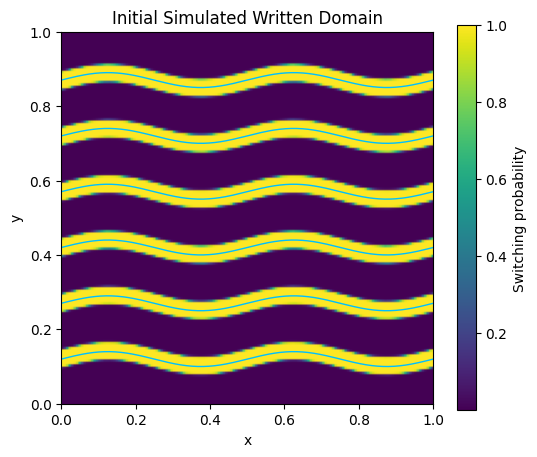

In [10]:
# ============================================================
# 8. Test initial trajectory before optimization
# ============================================================

points_per_line = 200

points, voltages, n_lines = make_trajectory(
    line_spacing=0.15,
    voltage=3.0,
    trajectory_amplitude=0.02,
    trajectory_frequency=2.0,
    trajectory_phase=0.0,
    trajectory_offset=0.1,
    points_per_line=points_per_line,
    x_min=0.0,
    x_max=1.0,
    y_min=0.0,
    y_max=1.0,
    serpentine=True
)

print("Initial number of lines:", n_lines.numpy())

switch_probability = simulate_written_domain(
    grid_points=grid_points,
    trajectory_points=points,
    voltage=voltages,
    base_width=0.007,
    voltage_width_gain=0.003,
    switching_threshold=1.0,
    softness=0.08,
    nx=nx,
    ny=ny
)

plot_domain_with_trajectory(
    switch_probability=switch_probability,
    trajectory_points=points,
    n_lines=n_lines,
    points_per_line=points_per_line,
    title="Initial Simulated Written Domain"
)

In [11]:
# ============================================================
# 9. Define trainable parameters
# ============================================================

line_spacing = tf.Variable(0.15, dtype=tf.float32, trainable=True)
voltage = tf.Variable(3.0, dtype=tf.float32, trainable=True)

trajectory_amplitude = tf.Variable(0.02, dtype=tf.float32, trainable=True)
trajectory_frequency = tf.Variable(2.0, dtype=tf.float32, trainable=True)
trajectory_phase = tf.Variable(0.0, dtype=tf.float32, trainable=True)
trajectory_offset = tf.Variable(0.1, dtype=tf.float32, trainable=True)

trainable_variables = [
    line_spacing,
    voltage,
    trajectory_amplitude,
    trajectory_frequency,
    trajectory_phase,
    trajectory_offset
]

optimizer = keras.optimizers.Adam(learning_rate=0.01)

In [12]:
# ============================================================
# 10. Optimization loop
# ============================================================

loss_history = []

for step in range(300):
    with tf.GradientTape() as tape:
        loss, loss_parts, switch_probability, trajectory_points = trajectory_optimization_loss(
            grid_points=grid_points,
            line_spacing=line_spacing,
            voltage=voltage,
            trajectory_amplitude=trajectory_amplitude,
            trajectory_frequency=trajectory_frequency,
            trajectory_phase=trajectory_phase,
            trajectory_offset=trajectory_offset,
            points_per_line=points_per_line,
            nx=nx,
            ny=ny
        )

    gradients = tape.gradient(loss, trainable_variables)

    valid_gradients_and_variables = [
        (grad, var)
        for grad, var in zip(gradients, trainable_variables)
        if grad is not None
    ]

    optimizer.apply_gradients(valid_gradients_and_variables)

    # Keep parameters in reasonable ranges
    line_spacing.assign(tf.clip_by_value(line_spacing, 0.05, 0.25))
    voltage.assign(tf.clip_by_value(voltage, 0.5, 6.0))
    trajectory_amplitude.assign(tf.clip_by_value(trajectory_amplitude, 0.0, 0.08))
    trajectory_frequency.assign(tf.clip_by_value(trajectory_frequency, 0.0, 6.0))
    trajectory_offset.assign(tf.clip_by_value(trajectory_offset, 0.0, 0.3))

    loss_history.append(loss.numpy())

    if step % 25 == 0:
        print(
            f"Step {step:03d} | "
            f"loss={loss.numpy():.4f} | "
            f"spacing={line_spacing.numpy():.4f} | "
            f"V={voltage.numpy():.4f} | "
            f"n_lines={loss_parts['n_lines'].numpy():.0f} | "
            f"reliability={loss_parts['reliability_loss'].numpy():.4f} | "
            f"merging={loss_parts['merging_loss'].numpy():.4f} | "
            f"boundary={loss_parts['boundary_loss'].numpy():.4f}"
        )

Step 000 | loss=3.3609 | spacing=0.1400 | V=3.0100 | n_lines=6 | reliability=0.4910 | merging=0.0364 | boundary=0.0000
Step 025 | loss=3.1692 | spacing=0.0908 | V=2.8177 | n_lines=11 | reliability=0.2417 | merging=0.1571 | boundary=0.0000
Step 050 | loss=3.2180 | spacing=0.1317 | V=2.7393 | n_lines=6 | reliability=0.4635 | merging=0.0351 | boundary=0.0000
Step 075 | loss=3.0301 | spacing=0.1227 | V=2.7679 | n_lines=6 | reliability=0.4169 | merging=0.0430 | boundary=0.0000
Step 100 | loss=2.8255 | spacing=0.1064 | V=2.7956 | n_lines=7 | reliability=0.3416 | merging=0.0676 | boundary=0.0000
Step 125 | loss=2.7539 | spacing=0.0830 | V=2.7661 | n_lines=9 | reliability=0.2176 | merging=0.1300 | boundary=0.0000
Step 150 | loss=3.2382 | spacing=0.0613 | V=2.5725 | n_lines=13 | reliability=0.1234 | merging=0.2331 | boundary=0.0000
Step 175 | loss=2.9329 | spacing=0.0617 | V=2.2664 | n_lines=14 | reliability=0.1912 | merging=0.1719 | boundary=0.0000
Step 200 | loss=2.5220 | spacing=0.0581 | V=2

In [13]:
# ============================================================
# 11. Final optimized result
# ============================================================

final_loss, final_parts, final_switch_probability, final_trajectory_points = trajectory_optimization_loss(
    grid_points=grid_points,
    line_spacing=line_spacing,
    voltage=voltage,
    trajectory_amplitude=trajectory_amplitude,
    trajectory_frequency=trajectory_frequency,
    trajectory_phase=trajectory_phase,
    trajectory_offset=trajectory_offset,
    points_per_line=points_per_line,
    nx=nx,
    ny=ny
)

print("Optimized parameters:")
print("line_spacing:", line_spacing.numpy())
print("voltage:", voltage.numpy())
print("trajectory_amplitude:", trajectory_amplitude.numpy())
print("trajectory_frequency:", trajectory_frequency.numpy())
print("trajectory_phase:", trajectory_phase.numpy())
print("trajectory_offset:", trajectory_offset.numpy())

print("\nFinal loss parts:")
for name, value in final_parts.items():
    print(name, value.numpy())

Optimized parameters:
line_spacing: 0.05
voltage: 1.5545869
trajectory_amplitude: 0.0692775
trajectory_frequency: 1.0264812
trajectory_phase: 1.0852538
trajectory_offset: 0.06183673

Final loss parts:
total_loss 2.352508
density_loss 0.05
reliability_loss 0.30985373
merging_loss 0.06779348
outside_switching_loss 0.06779348
geometric_merging_loss 0.0
voltage_loss 2.4167404
boundary_loss 0.0
coverage_loss 0.00014011444
n_lines 16.0


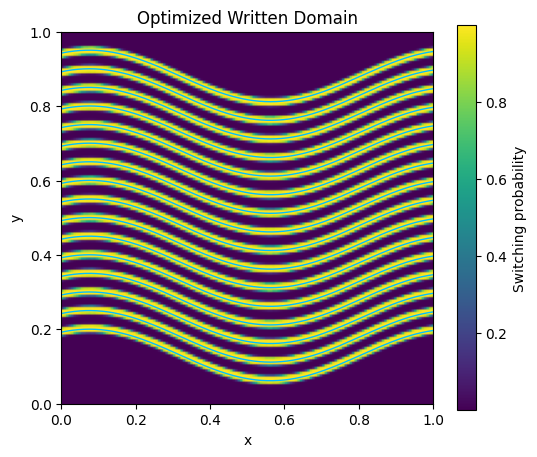

In [14]:
# ============================================================
# 12. Plot final optimized switching probability
# ============================================================

plot_domain_with_trajectory(
    switch_probability=final_switch_probability,
    trajectory_points=final_trajectory_points,
    n_lines=final_parts["n_lines"],
    points_per_line=points_per_line,
    title="Optimized Written Domain"
)

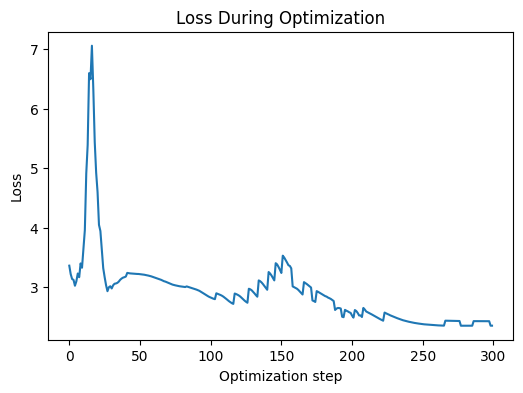

In [15]:
# ============================================================
# 13. Plot loss history
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Optimization step")
plt.ylabel("Loss")
plt.title("Loss During Optimization")
plt.show()

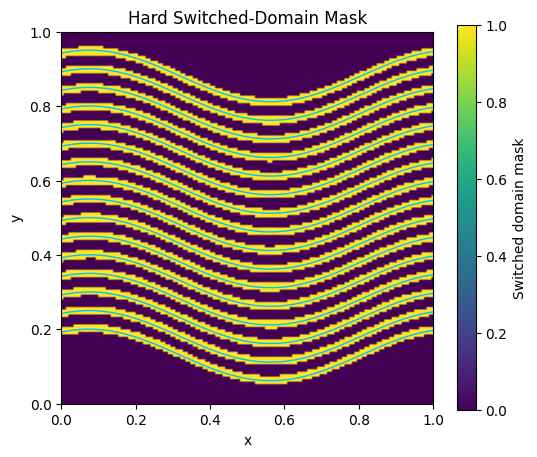

In [16]:
# ============================================================
# 14. Hard switched-domain mask
# ============================================================

hard_domain = final_switch_probability > 0.5

plot_domain_with_trajectory(
    switch_probability=hard_domain,
    trajectory_points=final_trajectory_points,
    n_lines=final_parts["n_lines"],
    points_per_line=points_per_line,
    title="Hard Switched-Domain Mask",
    hard_mask=True
)

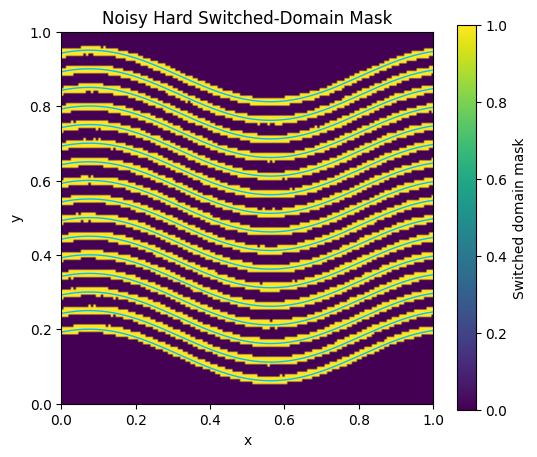

In [17]:
# ============================================================
# 15. Noisy robustness test
# ============================================================

noise_map = tf.random.normal(shape=(ny, nx), mean=0.0, stddev=1.0)

noisy_switch_probability = simulate_written_domain(
    grid_points=grid_points,
    trajectory_points=final_trajectory_points,
    voltage=voltage,
    base_width=0.007,
    voltage_width_gain=0.003,
    switching_threshold=1.0,
    softness=0.08,
    noise_map=noise_map,
    noise_strength=0.05,
    nx=nx,
    ny=ny
)

hard_noisy_domain = noisy_switch_probability > 0.5

plot_domain_with_trajectory(
    switch_probability=hard_noisy_domain,
    trajectory_points=final_trajectory_points,
    n_lines=final_parts["n_lines"],
    points_per_line=points_per_line,
    title="Noisy Hard Switched-Domain Mask",
    hard_mask=True
)